In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import emcee

In [3]:
np.random.seed(seed=6) # DEBUG

def poly_generate_parmas( N_dim, param_min=-5., param_max=5. ):
    """
    FUNC:
    Generates paramters of a polynomial function up to N_dim power
    ---
    INPUT:
    N_dim (int)             - number of polynomial powers
    param_min (float/array) - the minimum value of each power
    param_max (float/array) - the maximum value of each power
    """
    if type(N_dim) is not int:
        print('N_dim is not an integer.')
        return
    
    params = scipy.stats.uniform.rvs(loc=param_min, scale=param_max-param_min, size=(N_dim+1))

    return params

poly = np.polynomial.polynomial.Polynomial(poly_generate_parmas(5),[-1,1],[-1,1])

In [4]:
print(poly.__call__) # DEBUG (check the parameters)
np.random.seed(seed=6) # DEBUG
x,y = poly.linspace()
y += scipy.stats.norm.rvs(0,0.3,len(x))

<bound method ABCPolyBase.__call__ of Polynomial([ 3.92860151, -1.68020195,  3.21229123, -4.58303374, -3.9234332 ,
        0.95052064], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')>


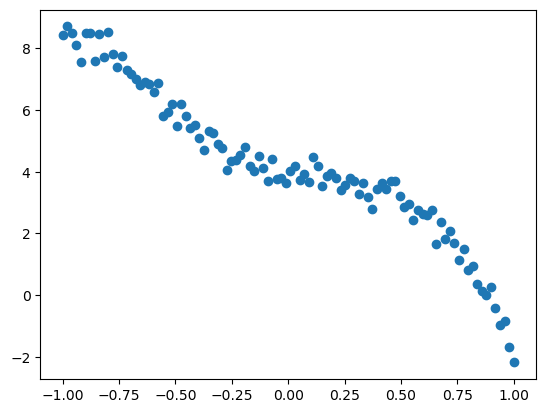

In [5]:
plt.figure()
plt.scatter(x,y)
plt.show()

Below I used AI prompt to make quick function to implement minimization of log-likelihood of the MSE loss function.

Prompt: *I have a polynomial with true values for the parameters. I want to give noise to the model by adding a Gaussian error with 0 mean and 0.3 standard deviation. I want to use emcee library to fit for the true parameters by using the mean squared error to maximize the likelihood. Could you help me implement this?*

You must install the tqdm library to use progress indicators with emcee


Running MCMC...

True parameters:       [ 1.  -2.   0.5]
Posterior mean:        [ 0.8766367  -2.04347384  0.54040979]
Posterior 1σ std dev:  [0.06345583 0.03596857 0.03416912]


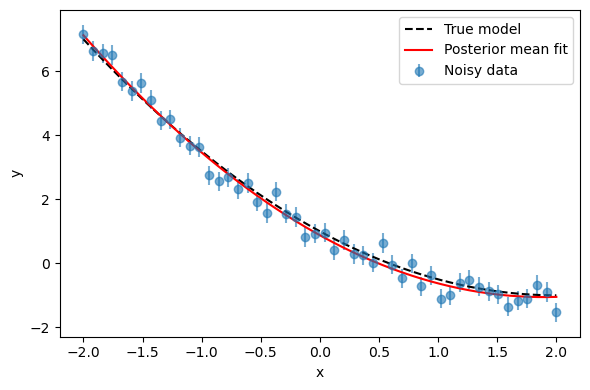

In [2]:

# ----------------------
# 1. Generate synthetic data
# ----------------------

# True polynomial: y = a0 + a1*x + a2*x^2
true_params = np.array([1.0, -2.0, 0.5])  # [a0, a1, a2]
sigma = 0.3  # measurement noise std

# x values
np.random.seed(42)
N = 50
x = np.linspace(-2, 2, N)

def poly_model(theta, x):
    """
    theta: array-like of polynomial coefficients [a0, a1, a2, ...]
    returns y_model for given x
    """
    # polyval expects highest power first, so reverse theta
    # If theta = [a0, a1, a2], polynomial is a0 + a1 x + a2 x^2
    # polyval coefficients: [a2, a1, a0]
    return np.polyval(theta[::-1], x)

# Generate noise-free and noisy observations
y_true = poly_model(true_params, x)
y_obs = y_true + np.random.normal(0.0, sigma, size=N)

# ----------------------
# 2. Define log-likelihood using Gaussian errors (MSE-based)
# ----------------------

def log_likelihood(theta, x, y, sigma):
    """
    Assume:
    y_i = model(theta, x_i) + N(0, sigma^2), with fixed known sigma.
    This is equivalent to using the MSE in the exponent of the likelihood.
    """
    y_model = poly_model(theta, x)
    residuals = y - y_model
    mse = np.mean(residuals**2)  # mean squared error

    # For Gaussian errors with variance sigma^2, the log-likelihood is:
    # logL = -0.5 * sum[(residuals^2) / sigma^2 + log(2*pi*sigma^2)]
    #      = -N/2 * [ log(2*pi*sigma^2) + MSE/sigma^2 ]
    N = len(y)
    return -0.5 * N * (np.log(2 * np.pi * sigma**2) + mse / sigma**2)

# ----------------------
# 3. Define priors and log-posterior
# ----------------------

def log_prior(theta):
    """
    Simple broad uniform priors for each parameter.
    Adjust ranges as needed.
    """
    a0, a1, a2 = theta
    if -10.0 < a0 < 10.0 and -10.0 < a1 < 10.0 and -10.0 < a2 < 10.0:
        return 0.0  # log(1)
    return -np.inf  # log(0), impossible

def log_posterior(theta, x, y, sigma):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, sigma)

# ----------------------
# 4. Set up and run emcee
# ----------------------

ndim = 3  # number of parameters: a0, a1, a2
nwalkers = 50
nsteps = 5000
burn_in = 1000

# Initialize walkers around a guess near the true parameters
initial_guess = true_params + 0.1 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior, args=(x, y_obs, sigma)
)

print("Running MCMC...")
sampler.run_mcmc(initial_state=initial_guess, nsteps=nsteps, progress=True)

# Discard burn-in and flatten the chains
flat_samples = sampler.get_chain(discard=burn_in, thin=10, flat=True)

# ----------------------
# 5. Inspect results
# ----------------------

# Compute posterior means and 1σ uncertainties
mcmc_mean = np.mean(flat_samples, axis=0)
mcmc_std = np.std(flat_samples, axis=0)

print("\nTrue parameters:      ", true_params)
print("Posterior mean:       ", mcmc_mean)
print("Posterior 1σ std dev: ", mcmc_std)

# ----------------------
# 6. Plot data and posterior predictive curve
# ----------------------

# Use posterior mean parameters for visualization
y_fit = poly_model(mcmc_mean, x)

plt.figure(figsize=(6,4))
plt.errorbar(x, y_obs, yerr=sigma, fmt="o", label="Noisy data", alpha=0.6)
plt.plot(x, y_true, "k--", label="True model")
plt.plot(x, y_fit, "r", label="Posterior mean fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()